In [4]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Métricas
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Visualização
import matplotlib.pyplot as plt

# Salvar modelo
import joblib

In [5]:
df = pd.read_excel(r"C:\Users\Laiza\Documents\projects\nlp-relacoes-semanticas-text-classification-pt\Dados_data.xlsx")
print(df.head())

    Ano  Período  Tarefa                                              Texto  \
0  1998        1       3                                 A leitura do mundo   
1  1998        1       3  Antes de aprender as letras, Pedro sabia ergue...   
2  1998        1       3  Assim como o próprio ser humano foi semeado pe...   
3  1998        1       3  colher a uva, esmagá-la e transformá-la em vin...   
4  1998        1       3        e se perguntou se uva é natureza ou cultura   

  Categoria Da Relação Tipo_ambiguidade Palavra_alvo  
0          Ambiguidade         metáfora      leitura  
1          Ambiguidade         metáfora       erguer  
2          Ambiguidade         metáfora      semeado  
3          Ambiguidade              NaN          NaN  
4          Ambiguidade         metáfora  transformar  


#### 2. Análise Exploratória de Dados

Nesta etapa, realizamos uma análise exploratória do dataset com o objetivo de compreender:

- a distribuição das categorias semânticas
- o equilíbrio entre as classes
- características dos textos (tamanho, variação)
- possíveis padrões linguísticos relevantes

Essa análise é fundamental para orientar decisões metodológicas e justificar o foco do projeto em fenômenos como a ambiguidade.

##### 2.1 Distribuicao das classes

Categoria Da Relação
Ambiguidade    206
Sinonímia       46
Antonímia       31
hiperonímia      1
Name: count, dtype: int64


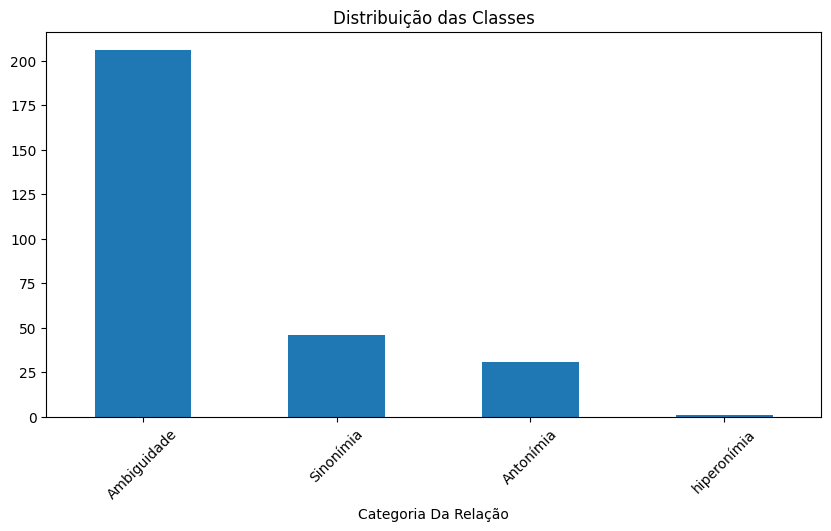

In [20]:
class_counts = df["Categoria Da Relação"].value_counts()

print(class_counts)

class_counts.plot(kind="bar", figsize=(10,5), title="Distribuição das Classes")
plt.xticks(rotation=45)
plt.show()

##### 2.2 Tamanho dos textos

In [21]:
df["text_length"] = df["Texto"].apply(len)

df["text_length"].describe()

count    284.000000
mean      74.799296
std       49.698510
min       10.000000
25%       44.000000
50%       64.000000
75%       91.250000
max      456.000000
Name: text_length, dtype: float64

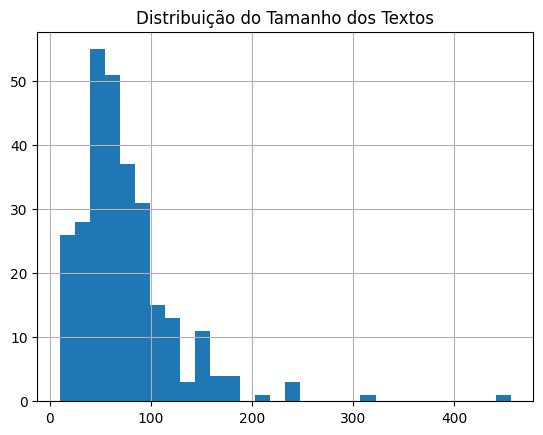

In [22]:
df["text_length"].hist(bins=30)
plt.title("Distribuição do Tamanho dos Textos")
plt.show()

A análise do tamanho dos textos mostra que:

- a média de caracteres é aproximadamente 75
- a maioria dos textos se concentra entre 40 e 100 caracteres
- há presença de outliers com textos mais longos

Essa distribuição sugere que o dataset é composto majoritariamente por enunciados curtos, o que pode dificultar a captura de relações semânticas mais complexas.

Em especial, a ambiguidade tende a depender de inferências contextuais, o que pode ser mais desafiador em textos curtos.

##### 2.3 Foco na ambiguidade

In [23]:
df[df["Categoria Da Relação"] == "Ambiguidade"]["Texto"].sample(10, random_state=42)


17     Mas cuja importância reside na descoberta do m...
11                                Viu também com a mente
271          Qual será o resultado desse tipo de equação
99                                     De bem com a vida
83     O casamento seguia um tédio, mas o clima estav...
115      Já pensei em ser mestre, mas isso não dá futuro
221              Um bom papo sempre cativa e abre portas
199    Outro dia peguei meu carro para ir a um evento...
183    Em tempos onde ser jovem é passaporte para a a...
226    Sua disposição, talento e carisma fizeram o pr...
Name: Texto, dtype: object

Assim, entende-se que dos exemplos classificados como ambiguidade revela que esses enunciados frequentemente apresentam:

- múltiplas interpretações possíveis
- dependência de contexto implícito
- uso de estruturas abertas ou incompletas
- necessidade de inferência pragmática

Essas características tornam a ambiguidade um fenômeno particularmente desafiador para modelos de NLP, que tendem a se basear em padrões superficiais de linguagem.

Dessa forma, o foco na ambiguidade se justifica não apenas pela sua frequência no dataset, mas também pela sua complexidade linguística.

### 3. Limpeza e preparacao dos dados

In [7]:
df = df[["Texto", "Categoria Da Relação"]].copy()

In [8]:
df = df.dropna()

In [9]:
# padronizar texto
df["Texto"] = df["Texto"].astype(str).str.strip()
df["Categoria Da Relação"] = df["Categoria Da Relação"].astype(str).str.strip()

In [10]:
# remover vazios
df = df[df["Texto"] != ""]
df = df[df["Categoria Da Relação"] != ""]

In [11]:
df = df.drop_duplicates()

In [13]:
print(df.shape)

(284, 2)


In [14]:
print(df["Categoria Da Relação"].value_counts())
df.head()

Categoria Da Relação
Ambiguidade    206
Sinonímia       46
Antonímia       31
hiperonímia      1
Name: count, dtype: int64


,Texto,Categoria Da Relação
0,A leitura do mundo,Ambiguidade
1,"Antes de aprender as letras, Pedro sabia ergue...",Ambiguidade
2,Assim como o próprio ser humano foi semeado pe...,Ambiguidade
3,"colher a uva, esmagá-la e transformá-la em vin...",Ambiguidade
4,e se perguntou se uva é natureza ou cultura,Ambiguidade


#### Separacao de variáveis e Divisao Treino/Teste

-------------------------

Nesta etapa, separamos os dados em:

- variável de entrada (**X**): texto
- variável alvo (**y**): categoria semântica

Em seguida, dividimos o dataset em conjuntos de treino e teste, garantindo que a proporção das classes seja mantida (stratify).

In [24]:
# verificar distribuição
class_counts = df["Categoria Da Relação"].value_counts()

# filtrar classes com pelo menos 2 exemplos
valid_classes = class_counts[class_counts >= 2].index
df = df[df["Categoria Da Relação"].isin(valid_classes)].copy()

print("Distribuição após filtro:")
print(df["Categoria Da Relação"].value_counts())

# separar X e y
X = df["Texto"]
y = df["Categoria Da Relação"]

# split treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Distribuição após filtro:
Categoria Da Relação
Ambiguidade    206
Sinonímia       46
Antonímia       31
Name: count, dtype: int64


A divisão dos dados foi realizada de forma estratificada, garantindo que a proporção das classes fosse mantida entre os conjuntos de treino e teste.

Além disso, classes com frequência muito baixa foram removidas temporariamente, uma vez que não permitem divisão adequada e poderiam comprometer o treinamento do modelo.

In [25]:
# checagens
print("\nShape treino:", X_train.shape)
print("Shape teste:", X_test.shape)

print("\nDistribuição treino:")
print(y_train.value_counts(normalize=True))

print("\nDistribuição teste:")
print(y_test.value_counts(normalize=True))


Shape treino: (226,)
Shape teste: (57,)

Distribuição treino:
Categoria Da Relação
Ambiguidade    0.725664
Sinonímia      0.163717
Antonímia      0.110619
Name: proportion, dtype: float64

Distribuição teste:
Categoria Da Relação
Ambiguidade    0.736842
Sinonímia      0.157895
Antonímia      0.105263
Name: proportion, dtype: float64


#### 4. Vetorizacao de Texto com TF-IDF


Nesta etapa, os textos são transformados em representações numéricas por meio da técnica **TF-IDF** (*Term Frequency–Inverse Document Frequency*).

Dessa forma, conseguimos converter os enunciados em vetores, considerando a relevância das palavras no conjunto de documentos, o que possibilita o uso de algoritmos de Machine Learning para classificação.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer


vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    max_features=5000
)

# ajustar no treino e transformar treino/teste
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Shape X_train_tfidf:", X_train_tfidf.shape)
print("Shape X_test_tfidf:", X_test_tfidf.shape)

Shape X_train_tfidf: (226, 3411)
Shape X_test_tfidf: (57, 3411)


A vetorização com TF-IDF foi aplicada utilizando unigramas e bigramas, permitindo capturar tanto palavras isoladas quanto combinações curtas de palavras.

A escolha dessa abordagem se deve ao seu bom desempenho como baseline em tarefas de classificação textual, além de oferecer uma representação simples e interpretável para a etapa inicial do projeto.

#### 5. Treinamento do Modelo Baseline com Regressao Logistica


Nesta etapa, treinamos um modelo baseline de classificação textual utilizando **Logistic Regression** sobre os vetores gerados por TF-IDF.

A escolha desse algoritmo se deve ao seu bom desempenho em tarefas de classificação de texto, além de servir como uma base sólida para comparações futuras com modelos mais robustos.

In [28]:

logreg_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

# treinar modelo
logreg_model.fit(X_train_tfidf, y_train)

print("Modelo treinado com sucesso.")

Modelo treinado com sucesso.


In [29]:
# prever no conjunto de teste
y_pred_logreg = logreg_model.predict(X_test_tfidf)

# métricas
accuracy = accuracy_score(y_test, y_pred_logreg)

print("Accuracy:", round(accuracy, 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_logreg))

Accuracy: 0.7368

Classification Report:

              precision    recall  f1-score   support

 Ambiguidade       0.77      0.98      0.86        42
   Antonímia       0.00      0.00      0.00         6
   Sinonímia       0.50      0.11      0.18         9

    accuracy                           0.74        57
   macro avg       0.42      0.36      0.35        57
weighted avg       0.65      0.74      0.66        57



O modelo baseline apresentou uma acurácia de aproximadamente 0.74, indicando um desempenho geral razoável.

No entanto, a análise detalhada por classe revela um comportamento desigual.

A classe **Ambiguidade** apresentou alto recall (0.98), indicando que o modelo foi capaz de identificar corretamente a maioria dos exemplos dessa categoria. Por outro lado, as classes **Sinonímia** e **Antonímia** apresentaram desempenho significativamente inferior, com valores de recall próximos de zero.

O modelo tende a privilegiar a classe majoritária, classificando grande parte dos exemplos como ambiguidade.

Esse comportamento pode ser explicado por dois fatores principais:

- o forte desbalanceamento do dataset
- a natureza mais difusa e abrangente da ambiguidade, que pode capturar padrões menos específicos

Do ponto de vista linguístico, esse resultado é particularmente relevante, pois indica que a ambiguidade pode funcionar como uma categoria "absorvente", na qual diferentes relações semânticas são confundidas.

Isso evidencia uma limitação importante de abordagens baseadas em TF-IDF, que tendem a capturar padrões superficiais de coocorrência de palavras, mas não necessariamente distinções semânticas mais finas.

##### 5.1 Matriz de Confusao

A matriz de confusão permite visualizar os acertos e erros do modelo por classe, facilitando a identificação de confusões frequentes entre categorias semânticas.

Essa análise é especialmente importante neste projeto, já que categorias semanticamente próximas ou ambíguas podem apresentar maior dificuldade de separação.

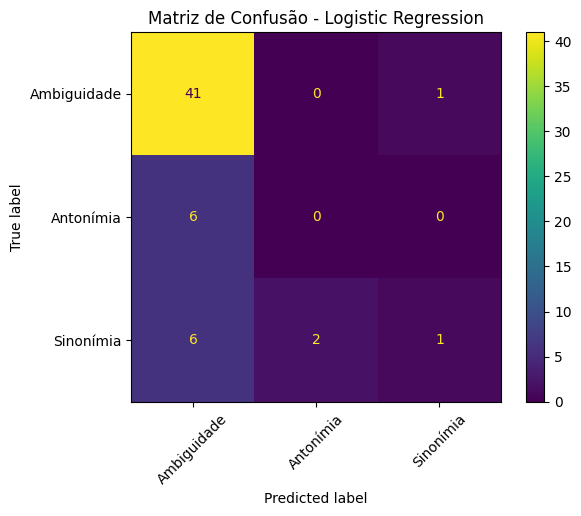

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_logreg, labels=logreg_model.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logreg_model.classes_)
disp.plot(xticks_rotation=45)
plt.title("Matriz de Confusão - Logistic Regression")
plt.show()

A matriz de confusão evidencia um comportamento fortemente enviesado do modelo em direção à classe **Ambiguidade**.

Observa-se que:

- a maioria dos exemplos de ambiguidade é corretamente classificada
- todos os exemplos de antonímia foram classificados como ambiguidade
- a maior parte dos exemplos de sinonímia também foi classificada como ambiguidade

Esse padrão indica que o modelo tende a utilizar a ambiguidade como uma categoria dominante ou padrão, absorvendo exemplos de outras classes.

Do ponto de vista linguístico, esse comportamento é significativo, pois sugere que:

- a ambiguidade pode compartilhar características superficiais com outras relações semânticas
- modelos baseados em TF-IDF não conseguem capturar distinções semânticas mais finas
- relações como sinonímia e antonímia exigem compreensão mais estruturada do significado

Assim, a matriz de confusão reforça a hipótese de que a ambiguidade representa um fenômeno semanticamente mais difuso e difícil de delimitar, o que impacta diretamente o desempenho de modelos tradicionais de NLP.

## Considerações sobre a Anotação do Dataset

Durante a construção do dataset, foi necessário atribuir uma única relação semântica a cada enunciado, de forma a viabilizar a tarefa de classificação.

No entanto, essa decisão implica uma simplificação de um fenômeno linguístico mais complexo, uma vez que uma mesma frase pode apresentar simultaneamente múltiplas relações semânticas.

Dessa forma, a anotação realizada representa uma escolha analítica, e não uma descrição exaustiva do comportamento semântico do enunciado.

Essa simplificação pode introduzir ambiguidades nos próprios rótulos, especialmente em casos onde a ambiguidade coexiste com outras relações, como sinonímia ou antonímia.

Do ponto de vista computacional, isso pode impactar o desempenho do modelo, que passa a lidar com categorias que não são mutuamente exclusivas na prática.

Assim, parte das dificuldades observadas na classificação pode ser atribuída não apenas às limitações do modelo, mas também à própria natureza do processo de anotação.

In [33]:
errors_df = pd.DataFrame({
    "texto": X_test,
    "real": y_test,
    "predito": y_pred_logreg
})

errors = errors_df[errors_df["real"] != errors_df["predito"]]

errors.head(10)

,texto,real,predito
269,Doce e amarga ilusão,Antonímia,Ambiguidade
254,"Nas faixas mais elevadas, o imposto ainda é mu...",Sinonímia,Antonímia
166,A visibilidade da água não é boa,Sinonímia,Ambiguidade
251,Cobrar dos alunos de famílias mais ricas,Sinonímia,Antonímia
259,blogueiras e suas refeições exemplares,Ambiguidade,Sinonímia
257,O ensino público gratuito não beneficia apenas...,Antonímia,Ambiguidade
256,O ensino público gratuito não beneficia apenas...,Sinonímia,Ambiguidade
165,[...] e depois aproveitar para pular no mar,Sinonímia,Ambiguidade
218,No sobe e desce de Porto Alegre,Antonímia,Ambiguidade
239,Eis a pista para a salvação: a biblioteca do f...,Sinonímia,Ambiguidade


A análise dos erros revela que muitos dos enunciados classificados incorretamente apresentam características que permitem múltiplas interpretações.

Em diversos casos, frases rotuladas como sinonímia ou antonímia também podem ser interpretadas como ambíguas, dependendo do contexto ou da leitura adotada.

Esse comportamento sugere que o modelo não está apenas cometendo erros aleatórios, mas refletindo uma dificuldade inerente à própria tarefa, na qual as categorias semânticas não são mutuamente exclusivas.

Dessa forma, os erros observados reforçam a hipótese de que a ambiguidade pode coexistir com outras relações semânticas, funcionando como uma dimensão transversal do significado.